### **Import the necessary libraries**

In [1]:
import nltk
import spacy 

import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline

### **Load the dataset**

In [2]:
from datasets import load_dataset

dataset = load_dataset("tdtunlp/open_subtitles_envi")
dataset

C:\Users\Administrator\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Administrator\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Administrator\.cache\huggingface\hub\datasets--tdtunlp--open_subtitles_envi. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https:

DatasetDict({
    train: Dataset({
        features: ['en', 'vi'],
        num_rows: 3505276
    })
})

In [3]:
mydata = dataset['train'].to_pandas()
mydata.head(10)

,en,vi
0,"Previously on ""The Blacklist""...",Trong phần trước của phim
1,- You want to call your daddy?,- Cháu muốn gọi cho bố hả?
2,"- Yeah, I want to tell him I'm okay.","- Vâng, cháu muốn nói với bố là cháu vẫn ổn."
3,Okay.,Được rồi.
4,Lizzy...,Lizzy...
5,Be careful of your husband.,Hãy cẩn thận với chồng cô.
6,I can only lead you to the truth.,Tôi chỉ có thể dẫn dắt cô tìm ra sự thật
7,I can't make you believe it.,Tôi không thể khiến cô tin điều đó.
8,She's calling herself Jolene Parker.,Cô ta tự gọi cho mình Jolene Parker.
9,"Elizabeth Keen is not your wife, she's your ta...","Elizabeth Keen không phải vợ anh, cô ta là mục..."


In [4]:
mydata.shape

(3505276, 2)

In [5]:
mydata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3505276 entries, 0 to 3505275
Data columns (total 2 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   en      object
 1   vi      object
dtypes: object(2)
memory usage: 53.5+ MB


We can see here, our dataset have 3,502,276 rows (sentences); and have 2 columns ('en' - English sentence, 'vi' - Vietnamese sentence)

### **Check for missing values**

In [6]:
mydata.isnull().sum()

en    0
vi    0
dtype: int64

We can see here, our dataset have no missing values

### **Check for Duplicates**

In [7]:
mydata.duplicated().sum()

np.int64(449663)

In [8]:
mydata.drop_duplicates(inplace=True)

In [9]:
mydata.shape

(3055613, 2)

### **Basic Statistics**

**Word Count**

In [10]:
mydata['en_words_count'] = mydata['en'].apply(lambda x: len(x.split()))
mydata['vi_words_count'] = mydata['vi'].apply(lambda x: len(x.split()))


In [11]:
print(f"The number of English words count: {mydata['en_words_count'].sum()} words")

The number of English words count: 20319743 words


In [12]:
print(f"The number of Vietnamese words count: {mydata['vi_words_count'].sum()} words")

The number of Vietnamese words count: 24578909 words


In [13]:
mydata.describe().map('{:,.2f}'.format)

,en_words_count,vi_words_count
count,"3,055,613.00","3,055,613.00"
mean,6.65,8.04
std,4.60,5.52
min,1.00,1.00
25%,4.00,4.00
50%,6.00,7.00
75%,8.00,10.00
max,93.00,143.00


In [14]:
def sentences_length(len_data):
    plt.figure(figsize=(15, 7), dpi=300)
    sns.set_style('darkgrid')
    sns.histplot(x=len_data, kde=True, binwidth=1) 
    plt.title('Sentences length histogram', fontsize=15, fontweight='bold')
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
    plt.xlabel('Length', fontweight='bold')
    plt.ylabel('Frequency', fontweight='bold')
    plt.show()

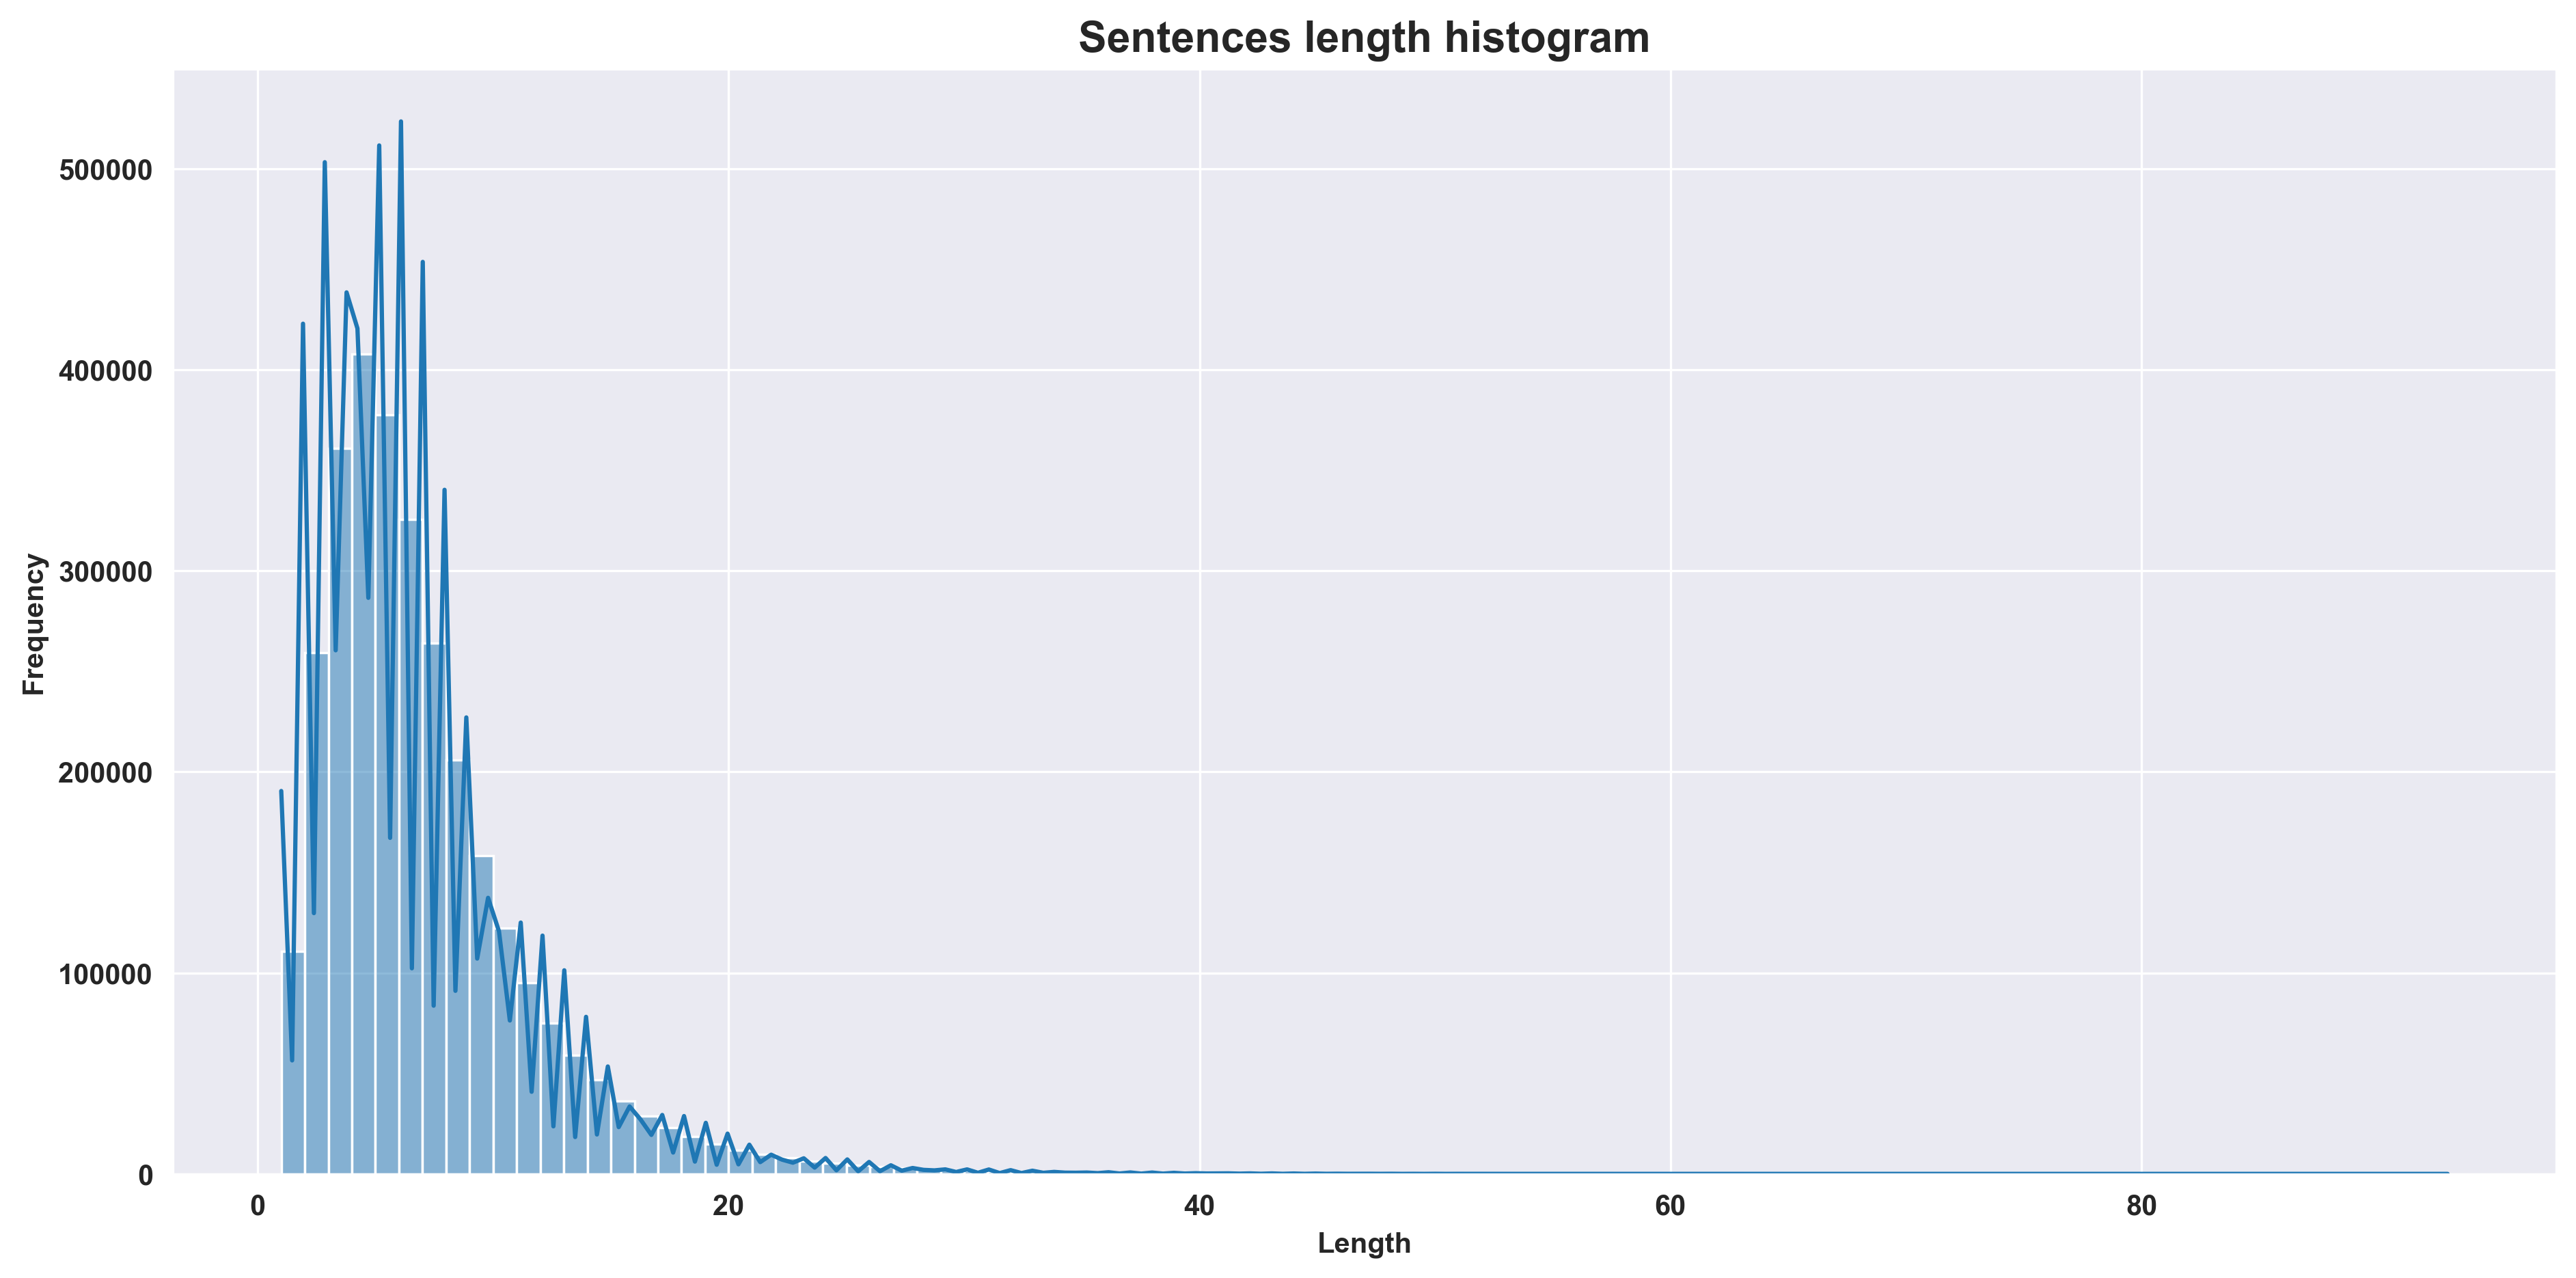

In [15]:
sentences_length(mydata['en_words_count'])

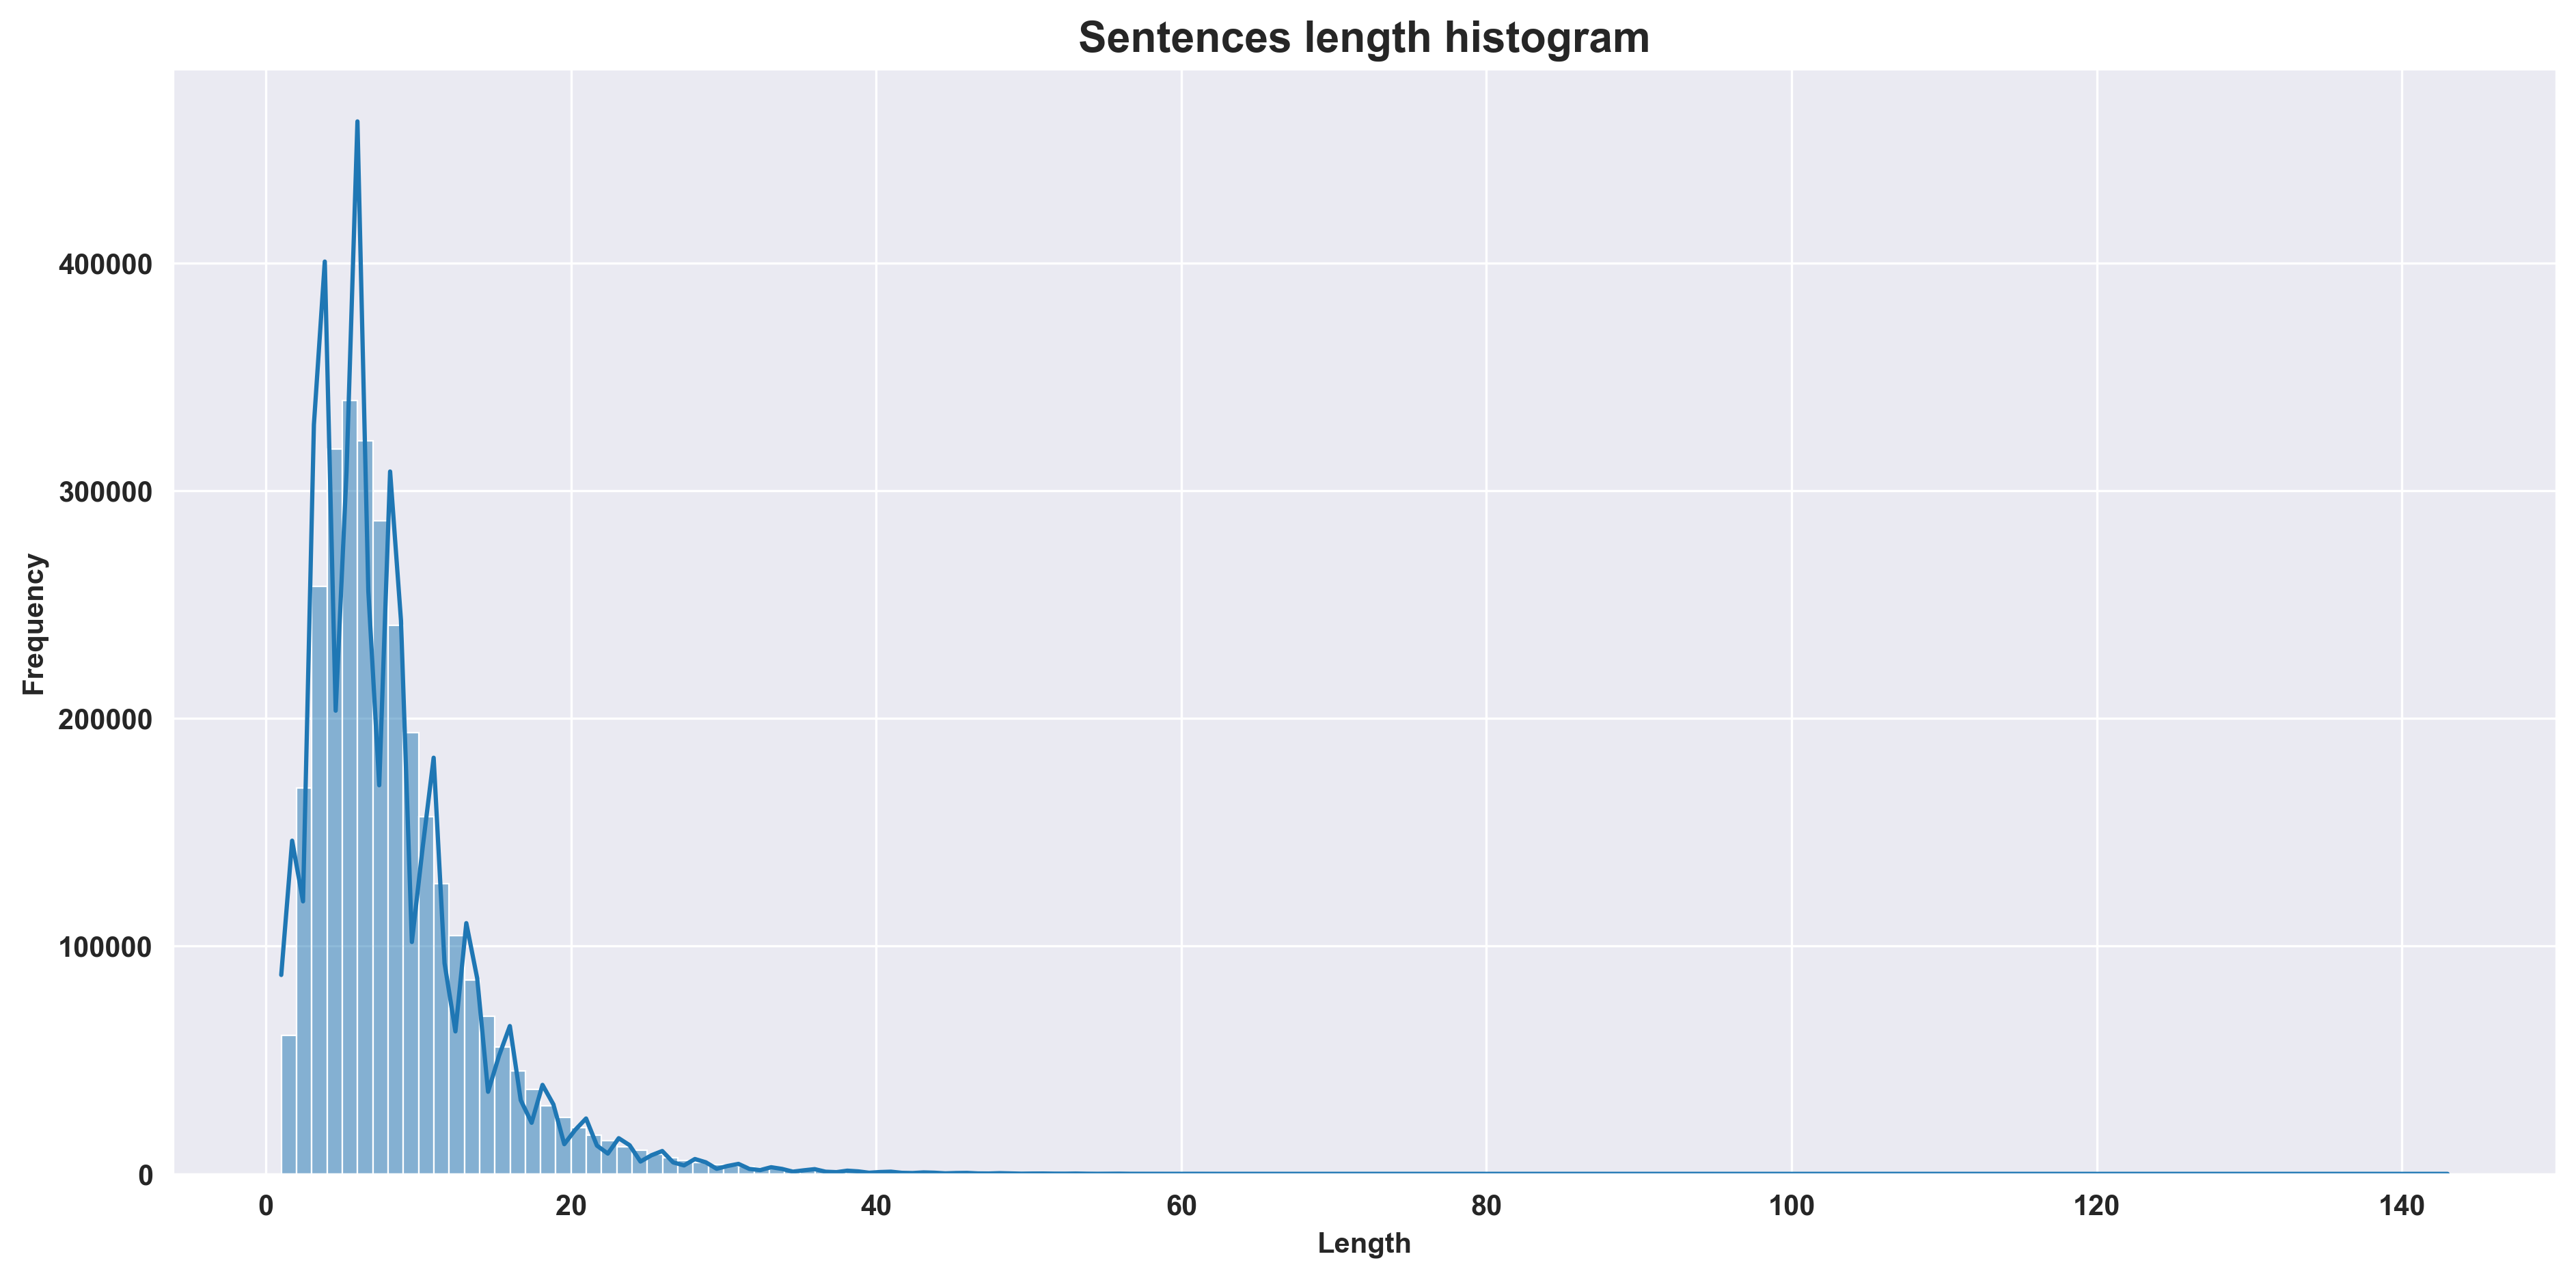

In [16]:
sentences_length(mydata['vi_words_count'])

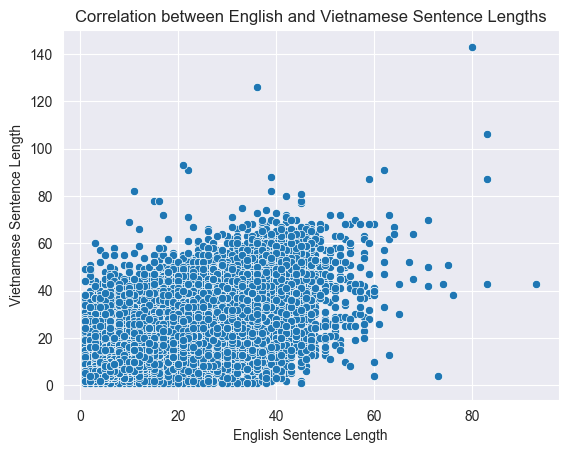

Correlation Matrix:
                 en_words_count  vi_words_count
en_words_count        1.000000        0.858141
vi_words_count        0.858141        1.000000


In [17]:
sns.scatterplot(x=mydata['en_words_count'], y=mydata['vi_words_count'])
plt.xlabel("English Sentence Length")
plt.ylabel("Vietnamese Sentence Length")
plt.title("Correlation between English and Vietnamese Sentence Lengths")
plt.show()

correlation = mydata[['en_words_count', 'vi_words_count']].corr()
print("Correlation Matrix:\n", correlation)


**Word Frequency**

In [18]:
from collections import Counter 
english_words = ' '.join(mydata['en']).split()
vietnamese_words = ' '.join(mydata['vi']).split()

english_counter = Counter(english_words)
vietnamese_counter = Counter(vietnamese_words)

In [19]:
# english_counter

In [20]:
# vietnamese_counter

In [21]:
def plot_top_words_pie_chart(word_freq):
    """
    Plots a pie chart for the top 20 words in the given frequency dictionary using seaborn for consistent colors.

    :param word_freq: Dictionary of word frequencies {word: frequency}
    """
    # Sort the dictionary by frequency and get the top 20 words
    sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:10][::-1]

    # Split the keys (words) and values (frequencies)
    words, frequencies = zip(*sorted_words)

    # Generate a color palette
    colors = sns.color_palette("pastel", len(words))

    # Plot the pie chart
    plt.figure(figsize=(10, 8))
    wedges, texts, autotexts = plt.pie(
        frequencies, labels=words, autopct='%1.1f%%', startangle=90, colors=colors,
        textprops={'fontsize': 12}
    )
    plt.setp(autotexts, size=10, weight="bold")
    plt.title('Top 10 Word Occurrences', fontsize=16)
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()

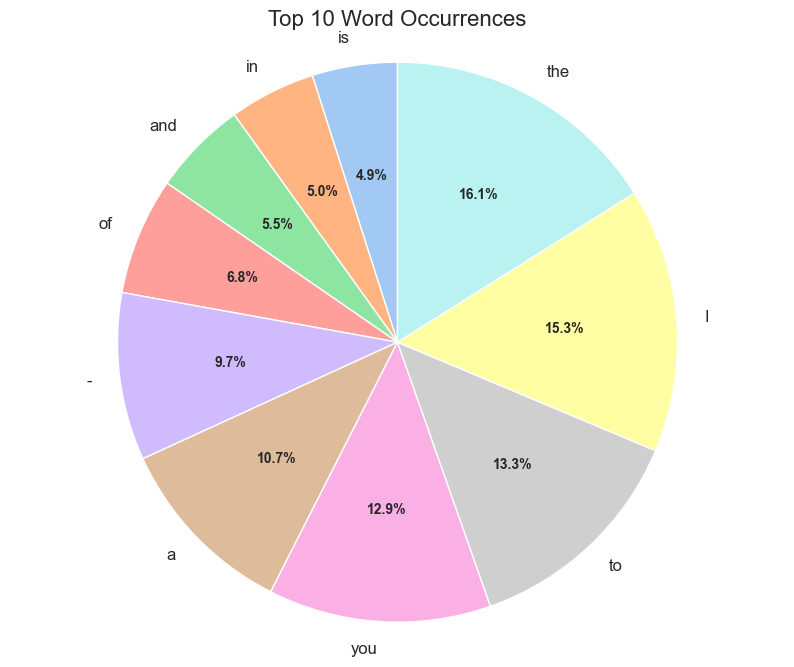

In [22]:
plot_top_words_pie_chart(english_counter)

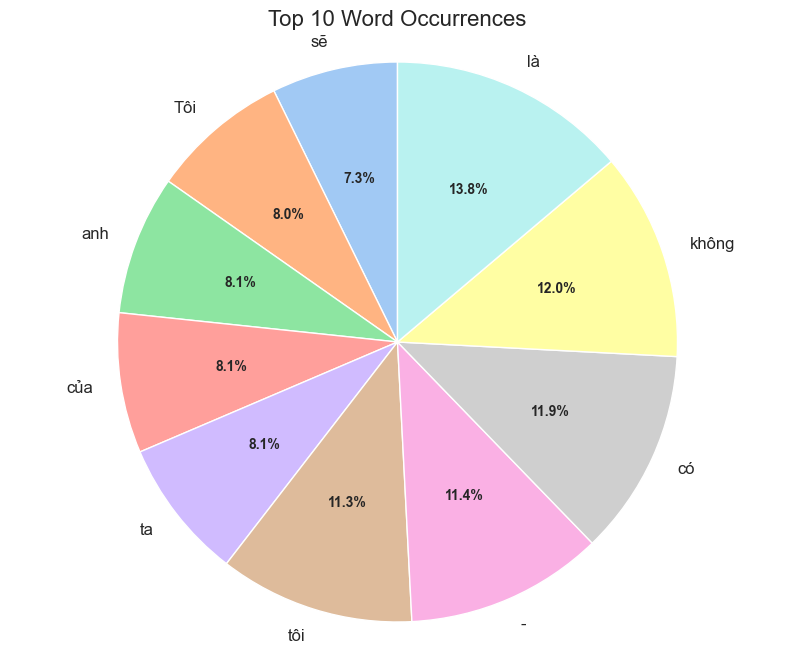

In [23]:
plot_top_words_pie_chart(vietnamese_counter)

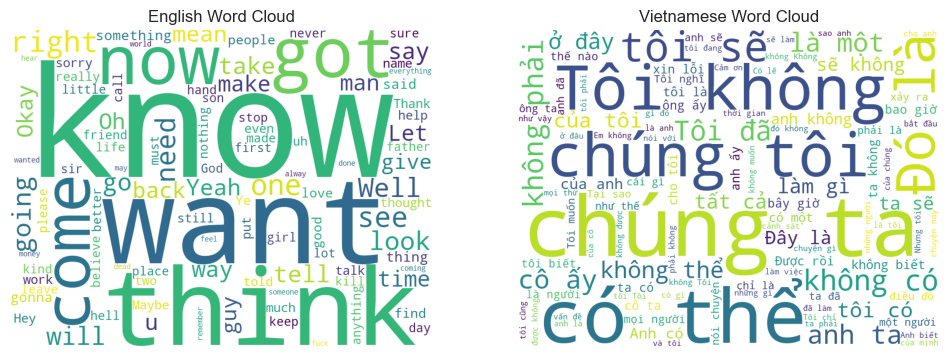

In [24]:
from wordcloud import WordCloud

en_text = " ".join(mydata['en'])
vi_text = " ".join(mydata['vi'])

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(WordCloud(width=800, height=600, background_color="white", max_words=100).generate(en_text))
plt.axis("off")
plt.title("English Word Cloud")

plt.subplot(1,2,2)
plt.imshow(WordCloud(width=800, height=600, background_color="white", max_words=100).generate(vi_text))
plt.axis("off")
plt.title("Vietnamese Word Cloud")

plt.show()

### **N-gram Analysis**

In [25]:
from sklearn.feature_extraction.text import CountVectorizer

In [26]:
def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx])
                  for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:10]

In [27]:
top_en_bigram = get_top_ngram(mydata['en'], n=2)
top_en_trigram = get_top_ngram(mydata['en'], n=3)

In [28]:
top_vi_bigram = get_top_ngram(mydata['vi'], n=2)
top_vi_trigram = get_top_ngram(mydata['vi'], n=3)

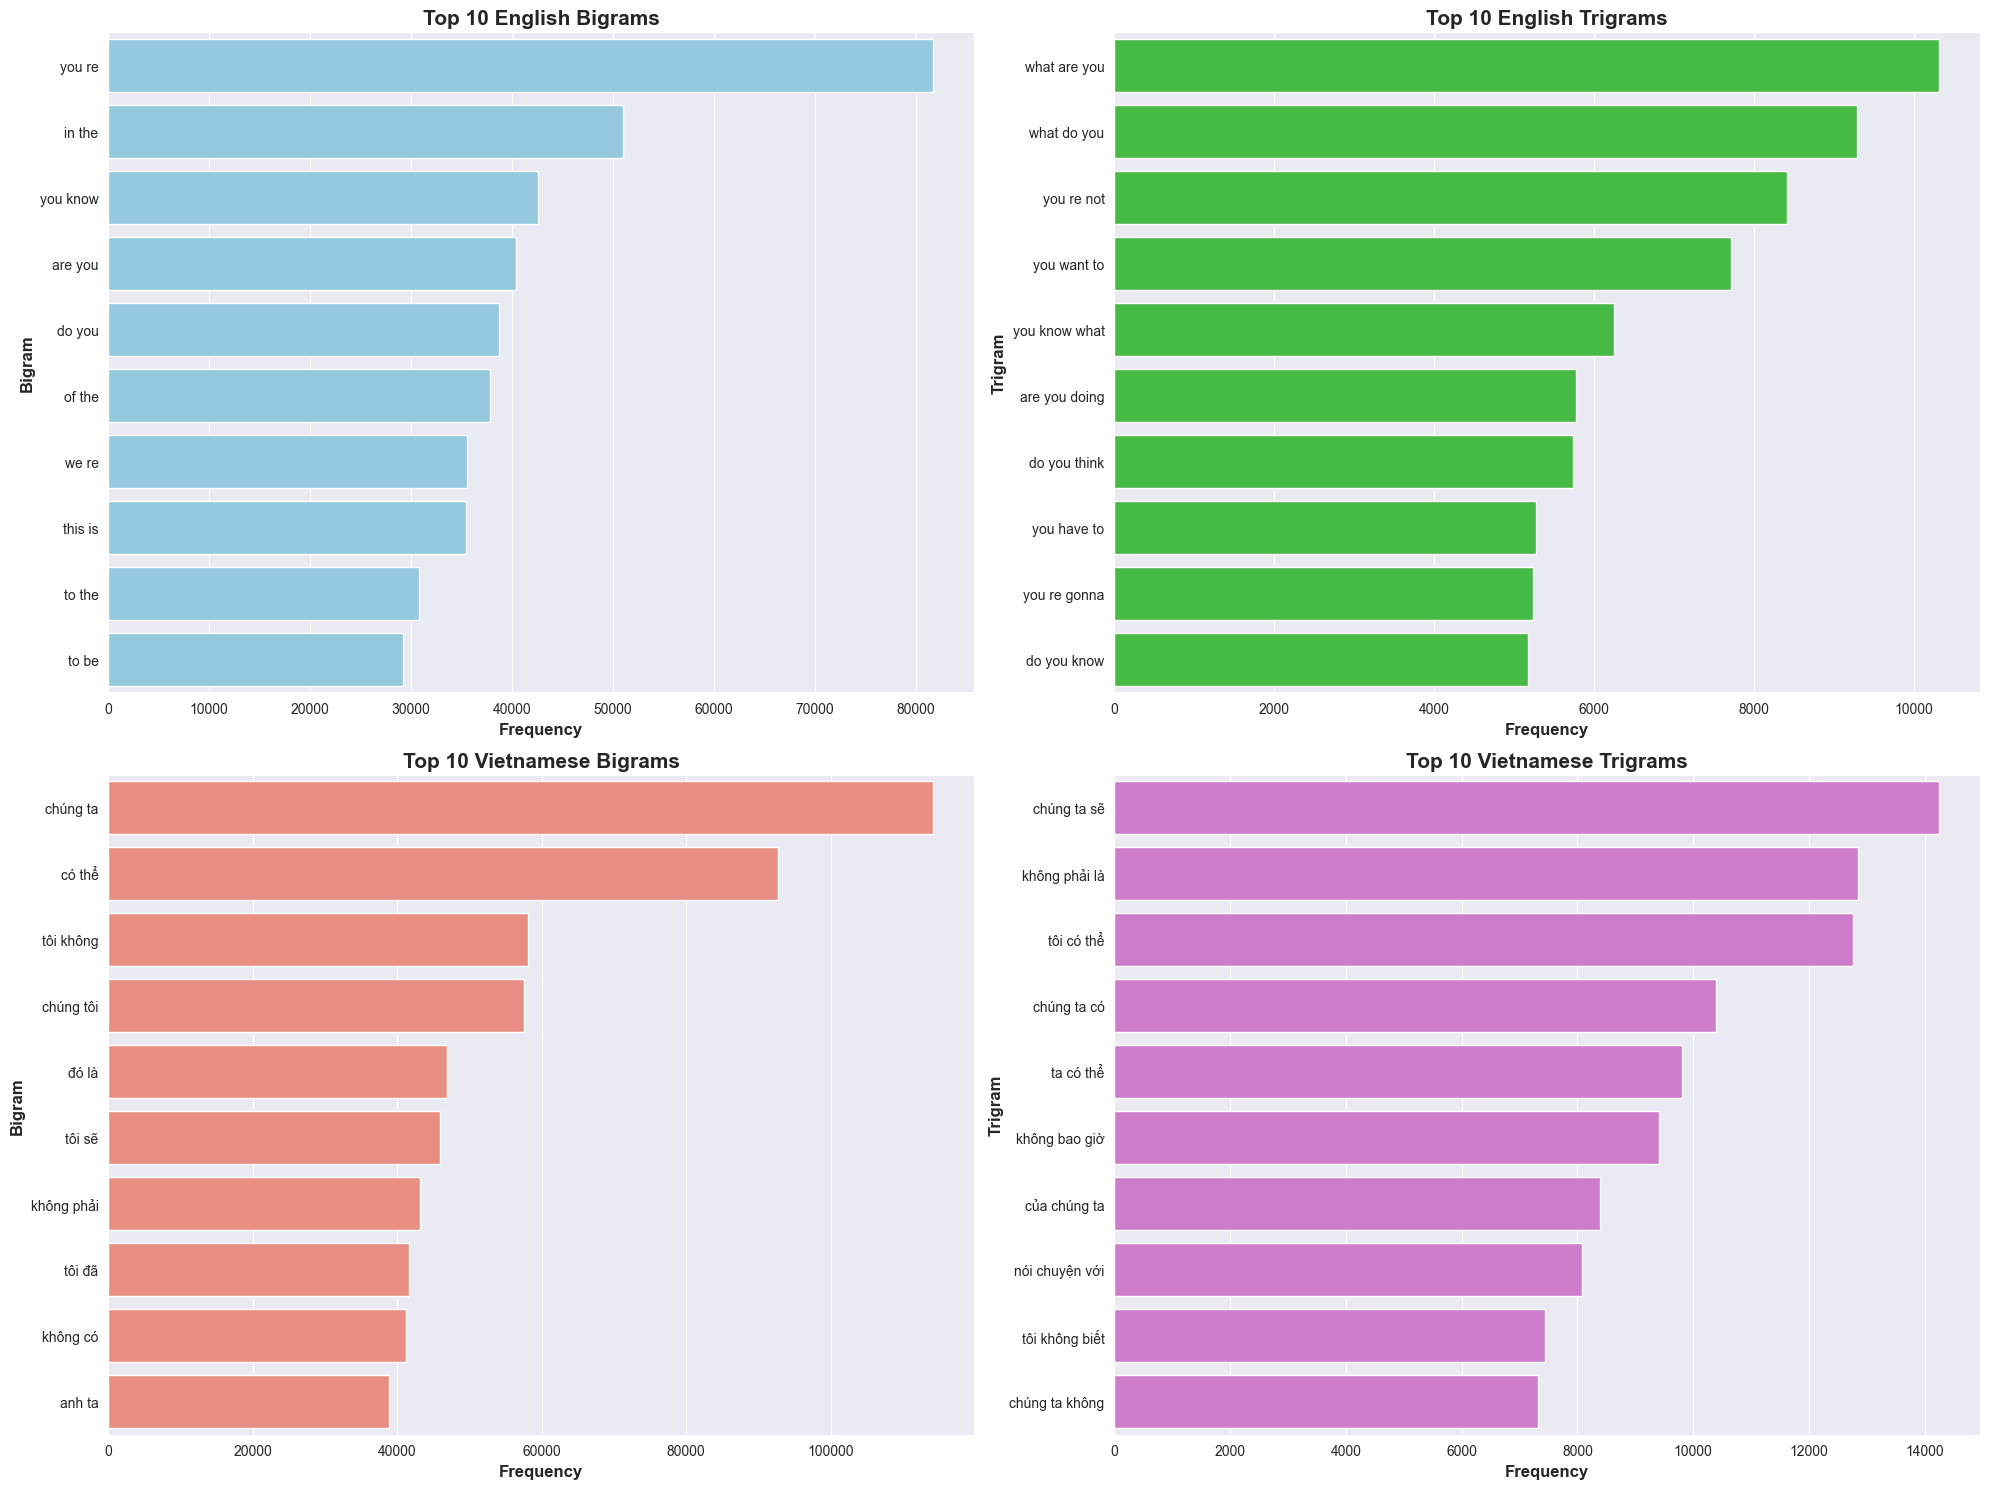

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

x, y = map(list, zip(*top_en_bigram))  # x: bigrams, y: frequencies
sns.barplot(x=y, y=x, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_xlabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Bigram', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Top 10 English Bigrams', fontsize=15, fontweight='bold')

x, y = map(list, zip(*top_en_trigram))  # x: trigrams, y: frequencies
sns.barplot(x=y, y=x, color='limegreen', ax=axes[0, 1])
axes[0, 1].set_xlabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Trigram', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Top 10 English Trigrams', fontsize=15, fontweight='bold')

x, y = map(list, zip(*top_vi_bigram))  # x: bigrams, y: frequencies
sns.barplot(x=y, y=x, color='salmon', ax=axes[1, 0])
axes[1, 0].set_xlabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Bigram', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Top 10 Vietnamese Bigrams', fontsize=15, fontweight='bold')

x, y = map(list, zip(*top_vi_trigram))  # x: trigrams, y: frequencies
sns.barplot(x=y, y=x, color='orchid', ax=axes[1, 1])
axes[1, 1].set_xlabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Trigram', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Top 10 Vietnamese Trigrams', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()
